<a href="https://colab.research.google.com/github/yatli24/CHC/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr


In [ ]:
import os
import glob

In [ ]:
# do it with glob
nmme_gfdl_path = '/content/drive/MyDrive/capstone_data/NMME/GFDL-SPEAR/prec/*.nc'
nmme_gfdl_files = glob.glob(nmme_gfdl_path)
GFDL = xr.open_mfdataset(nmme_gfdl_files, parallel=True)

print(GFDL)

<xarray.Dataset> Size: 14GB
Dimensions:  (S: 145, L: 12, M: 30, Y: 181, X: 360)
Coordinates:
  * L        (L) float32 48B 0.5 1.5 2.5 3.5 4.5 5.5 6.5 7.5 8.5 9.5 10.5 11.5
  * Y        (Y) float32 724B -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * M        (M) float32 120B 1.0 2.0 3.0 4.0 5.0 ... 26.0 27.0 28.0 29.0 30.0
  * X        (X) float32 1kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * S        (S) datetime64[ns] 1kB 1991-01-01 1991-02-01 ... 2025-01-01
Data variables:
    prec     (S, L, M, Y, X) float32 14GB dask.array<chunksize=(1, 12, 15, 181, 360), meta=np.ndarray>


In [ ]:
## Converting NMME to CHIRPS sturcture ##
GFDL = GFDL.assign_coords(X=(((GFDL.X + 180) % 360) - 180)).sortby(['X'])

In [ ]:
from re import X
nmme_gfdl_slice = GFDL['prec']

## Eastern East Africa ##
min_lat = -3.5
max_lat = 8.5
min_lon = 38
max_lon = 50


In [ ]:
nmme_gfdl_data = nmme_gfdl_slice.sel(Y = slice(min_lat, max_lat), X = slice(min_lon, max_lon))
print(nmme_gfdl_data)

<xarray.DataArray 'prec' (S: 145, L: 12, M: 30, Y: 12, X: 13)> Size: 33MB
dask.array<getitem, shape=(145, 12, 30, 12, 13), dtype=float32, chunksize=(1, 12, 15, 12, 13), chunktype=numpy.ndarray>
Coordinates:
  * L        (L) float32 48B 0.5 1.5 2.5 3.5 4.5 5.5 6.5 7.5 8.5 9.5 10.5 11.5
  * Y        (Y) float32 48B -3.0 -2.0 -1.0 0.0 1.0 2.0 3.0 4.0 5.0 6.0 7.0 8.0
  * M        (M) float32 120B 1.0 2.0 3.0 4.0 5.0 ... 26.0 27.0 28.0 29.0 30.0
  * S        (S) datetime64[ns] 1kB 1991-01-01 1991-02-01 ... 2025-01-01
  * X        (X) float32 52B 38.0 39.0 40.0 41.0 42.0 ... 47.0 48.0 49.0 50.0
Attributes:
    pointwidth:          0
    long_name:           Total Precipitation
    standard_name:       lwe_precipitation_rate
    file_missing_value:  -1e+34
    units:               mm/day


In [ ]:
nmme_gfdl_data = nmme_gfdl_data.rename({'Y':'latitude', 'X':'longitude', "M":"number", "S":"forcast_reference_time", "L":"forecastMonth"})

nmme_gfdl_data = nmme_gfdl_data.to_dataframe().reset_index()
nmme_gfdl_data['forcast_reference_time'] = pd.to_datetime(nmme_gfdl_data['forcast_reference_time'])

nmme_gfdl_data

,forcast_reference_time,forecastMonth,number,latitude,longitude,prec
0,1991-01-01,0.5,1.0,-3.0,38.0,1.917060
1,1991-01-01,0.5,1.0,-3.0,39.0,0.836918
2,1991-01-01,0.5,1.0,-3.0,40.0,0.408504
3,1991-01-01,0.5,1.0,-3.0,41.0,0.191893
4,1991-01-01,0.5,1.0,-3.0,42.0,0.155437
...,...,...,...,...,...,...
8143195,2025-01-01,11.5,30.0,8.0,46.0,2.581019
8143196,2025-01-01,11.5,30.0,8.0,47.0,1.921528
8143197,2025-01-01,11.5,30.0,8.0,48.0,1.237522
8143198,2025-01-01,11.5,30.0,8.0,49.0,1.262807


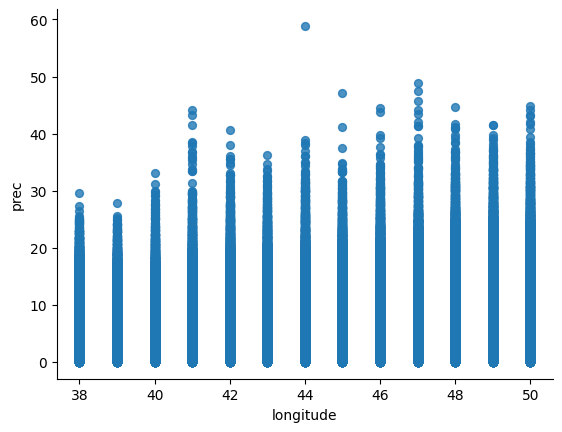

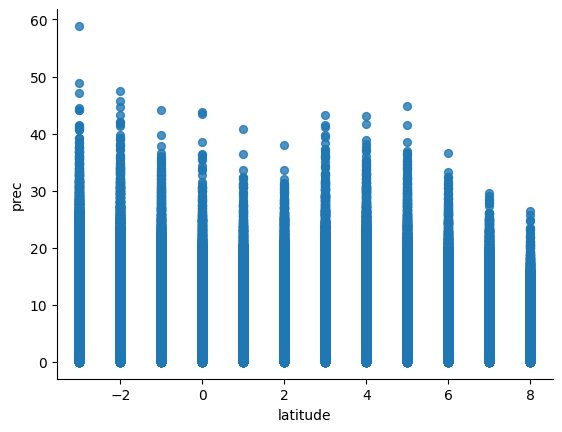

In [ ]:

nmme_gfdl_data.plot(kind='scatter', x='longitude', y='prec', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

nmme_gfdl_data.plot(kind='scatter', x='latitude', y='prec', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

1991 MONTHLY AVERAGE PRECIPITATION

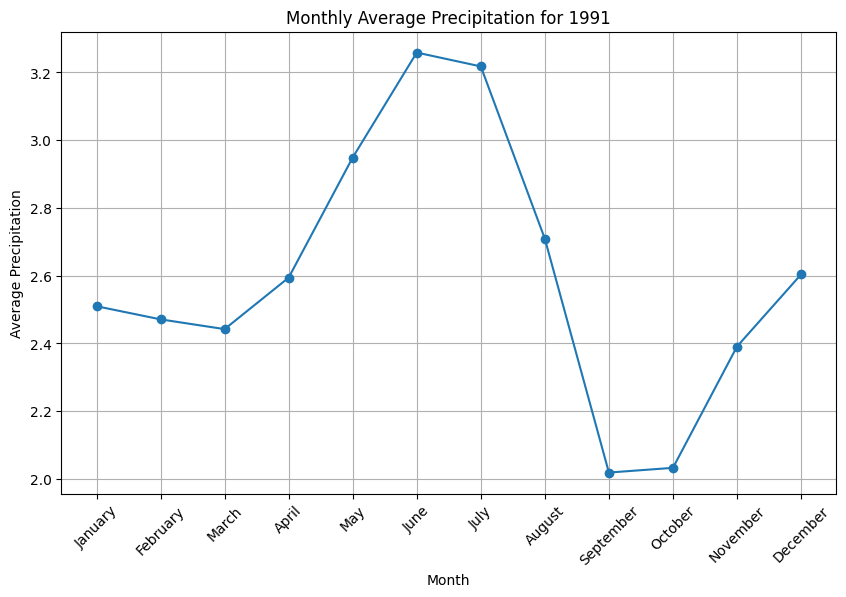

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import calendar

# year 1991
nmme_gfdl_data['Year'] = nmme_gfdl_data['forcast_reference_time'].dt.year
nmme_gfdl_data['Month'] = nmme_gfdl_data['forcast_reference_time'].dt.month

gfdl_1991 = nmme_gfdl_data[nmme_gfdl_data['Year'] == 1991]

# Grouping by month to calculate the monthly average of 'prec'
gfdl_1991_monthly_avg = gfdl_1991.groupby('Month')['prec'].mean().reset_index()

# Mapping month numbers to month names
gfdl_1991_monthly_avg['Month_Name'] = gfdl_1991_monthly_avg['Month'].apply(lambda x: calendar.month_name[x])

# Plot with month name mapped
plt.figure(figsize=(10, 6))
plt.plot(gfdl_1991_monthly_avg['Month_Name'], gfdl_1991_monthly_avg['prec'], marker='o')
plt.title('Monthly Average Precipitation for 1991')
plt.xlabel('Month')
plt.ylabel('Average Precipitation')
plt.grid(True)
plt.xticks(rotation=45)  # Rotating x-axis labels for better readability
plt.show()




LEAD TIME

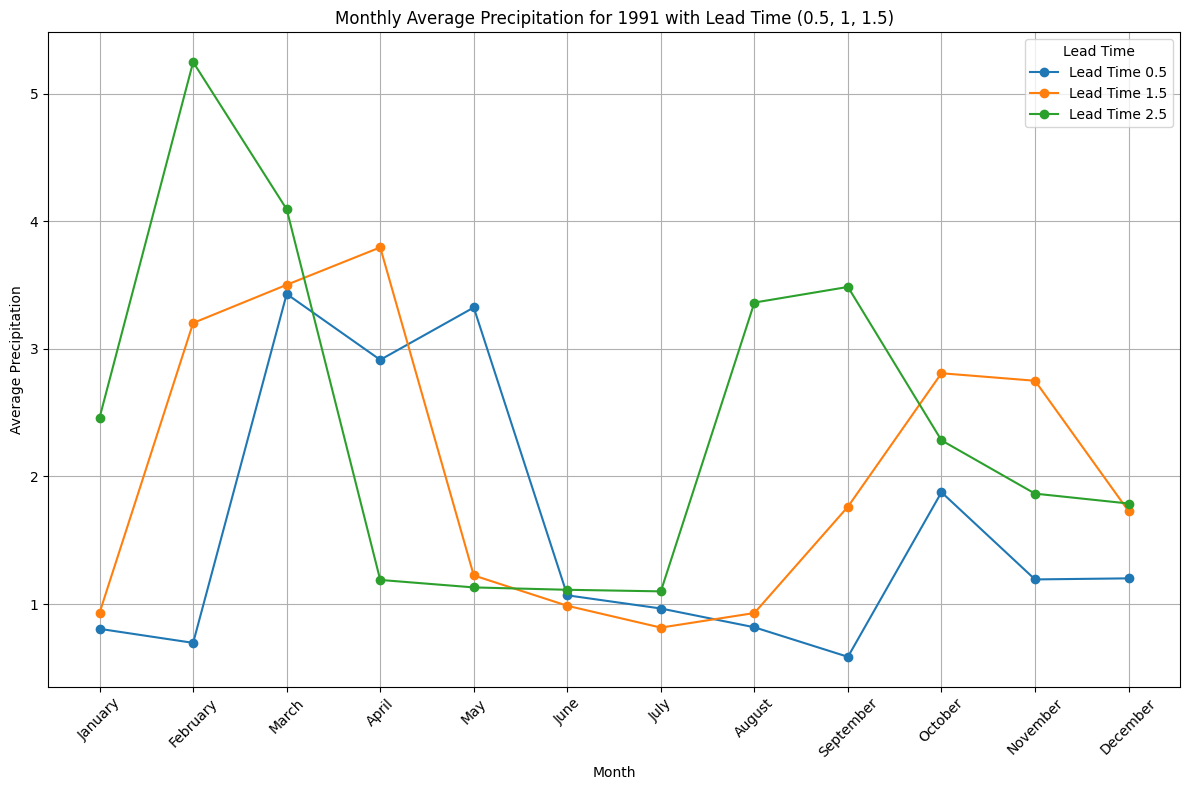

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import calendar

# Extracting Year and Month
nmme_gfdl_data['Year'] = nmme_gfdl_data['forcast_reference_time'].dt.year
nmme_gfdl_data['Month'] = nmme_gfdl_data['forcast_reference_time'].dt.month

# Filtering data for the year 1991
gfdl_1991 = nmme_gfdl_data[nmme_gfdl_data['Year'] == 1991]

# Grouping by Month and Lead Time (forecastMonth) to calculate the monthly average of 'prec'
gfdl_1991_monthly_avg = gfdl_1991.groupby(['Month', 'forecastMonth'])['prec'].mean().reset_index()

# Mapping month numbers to month names
gfdl_1991_monthly_avg['Month_Name'] = gfdl_1991_monthly_avg['Month'].apply(lambda x: calendar.month_name[x])

# Plot with month name and lead time
plt.figure(figsize=(12, 8))

# Plotting for lead times 0.5, 1, and 1.5
for lead_time in [0.5, 1.5, 2.5]:
    lead_data = gfdl_1991_monthly_avg[gfdl_1991_monthly_avg['forecastMonth'] == lead_time]
    plt.plot(lead_data['Month_Name'], lead_data['prec'], marker='o', label=f'Lead Time {lead_time}')

plt.title('Monthly Average Precipitation for 1991 with Lead Time (0.5, 1.5, 2.5)')
plt.xlabel('Month')
plt.ylabel('Average Precipitation')
plt.grid(True)
plt.xticks(rotation=45)  # Rotating x-axis labels for better readability
plt.legend(title='Lead Time')
plt.tight_layout()
plt.show()


OCTOBER PREC ACROSS ALL YEARS



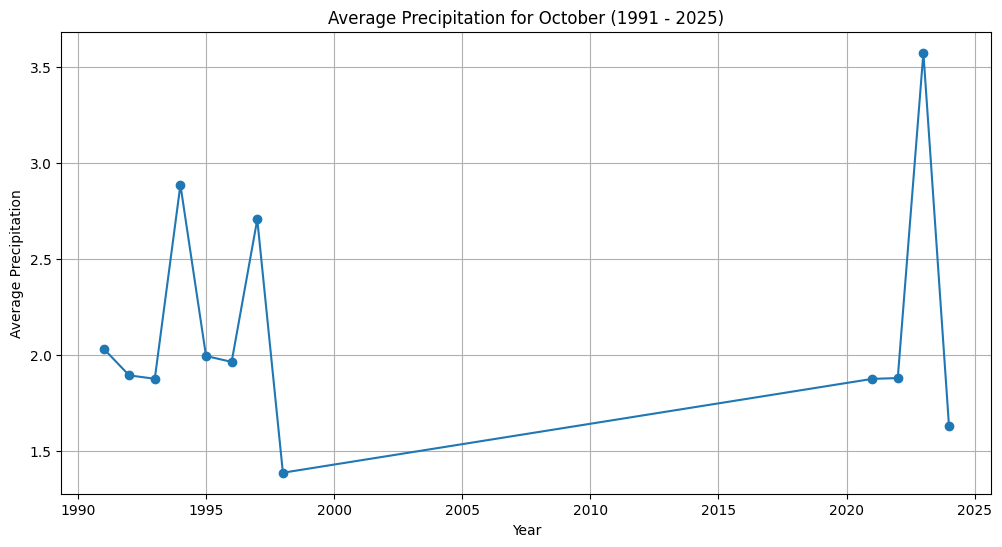

In [ ]:
# Selecting October data (Month = 10)
october_data = nmme_gfdl_data[nmme_gfdl_data['Month'] == 10]

# Calculating the average 'prec' for each year in October
october_avg_prec = october_data.groupby('Year')['prec'].mean().reset_index()

# Plotting the time series
plt.figure(figsize=(12, 6))
plt.plot(october_avg_prec['Year'], october_avg_prec['prec'], marker='o')
plt.title('Average Precipitation for October (1991 - 2025)')
plt.xlabel('Year')
plt.ylabel('Average Precipitation')
plt.grid(True)
plt.show()



SOUTH SUDAN

In [ ]:
from re import X
ssudan_gfdl_slice = GFDL['prec']


## South Sudan ##
min_lat = 3.5
max_lat = 12.5
min_lon = 25
max_lon = 35




In [ ]:
ssudan_gfdl_data = ssudan_gfdl_slice.sel(Y = slice(min_lat, max_lat), X = slice(min_lon, max_lon))
print(ssudan_gfdl_data)

<xarray.DataArray 'prec' (S: 145, L: 12, M: 30, Y: 9, X: 11)> Size: 21MB
dask.array<getitem, shape=(145, 12, 30, 9, 11), dtype=float32, chunksize=(1, 12, 15, 9, 11), chunktype=numpy.ndarray>
Coordinates:
  * L        (L) float32 48B 0.5 1.5 2.5 3.5 4.5 5.5 6.5 7.5 8.5 9.5 10.5 11.5
  * Y        (Y) float32 36B 4.0 5.0 6.0 7.0 8.0 9.0 10.0 11.0 12.0
  * M        (M) float32 120B 1.0 2.0 3.0 4.0 5.0 ... 26.0 27.0 28.0 29.0 30.0
  * S        (S) datetime64[ns] 1kB 1991-01-01 1991-02-01 ... 2025-01-01
  * X        (X) float32 44B 25.0 26.0 27.0 28.0 29.0 ... 32.0 33.0 34.0 35.0
Attributes:
    pointwidth:          0
    long_name:           Total Precipitation
    standard_name:       lwe_precipitation_rate
    file_missing_value:  -1e+34
    units:               mm/day


In [ ]:
ssudan_gfdl_data = ssudan_gfdl_data.rename({'Y':'latitude', 'X':'longitude', "M":"number", "S":"forcast_reference_time", "L":"forecastMonth"})

ssudan_gfdl_data = ssudan_gfdl_data.to_dataframe().reset_index()
ssudan_gfdl_data['forcast_reference_time'] = pd.to_datetime(ssudan_gfdl_data['forcast_reference_time'])

ssudan_gfdl_data

,forcast_reference_time,forecastMonth,number,latitude,longitude,prec
0,1991-01-01,0.5,1.0,4.0,25.0,0.412521
1,1991-01-01,0.5,1.0,4.0,26.0,1.751562
2,1991-01-01,0.5,1.0,4.0,27.0,2.662631
3,1991-01-01,0.5,1.0,4.0,28.0,1.229604
4,1991-01-01,0.5,1.0,4.0,29.0,0.445705
...,...,...,...,...,...,...
5167795,2025-01-01,11.5,30.0,12.0,31.0,0.000002
5167796,2025-01-01,11.5,30.0,12.0,32.0,0.000053
5167797,2025-01-01,11.5,30.0,12.0,33.0,0.000072
5167798,2025-01-01,11.5,30.0,12.0,34.0,0.000075


# # Grouping by month to calculate the average precipitation for each month across all years
monthly_precip_avg = df.groupby('month')['precip'].mean()

# Plotting the average precipitation for each month
plt.figure(figsize=(12, 6))
bars = monthly_precip_avg.plot(kind='bar', color='brown')

# Adding the average precipitation value on top of each bar
for i, value in enumerate(monthly_precip_avg):
    plt.text(i, value + 0.1, f'{value:.2f}', ha='center', va='bottom', fontsize=10)

plt.title('Average Precipitation by Month across all years')
plt.xlabel('Month')
plt.ylabel('Average Precipitation')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# load CHIRPS
chirps_path = '/content/drive/MyDrive/capstone_data/CHIRPS/*.nc'

chrip_files = glob.glob(chirps_path)

CHIRPS = xr.open_mfdataset(chrip_files, parallel=True)

#print(CHIRPS)
chirps_ts = CHIRPS['precip']
print(chirps_ts)

<xarray.DataArray 'precip' (time: 528, latitude: 2000, longitude: 7200)> Size: 30GB
dask.array<open_dataset-precip, shape=(528, 2000, 7200), dtype=float32, chunksize=(26, 100, 360), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 8kB -49.97 -49.92 -49.88 ... 49.87 49.92 49.97
  * longitude  (longitude) float32 29kB -180.0 -179.9 -179.9 ... 179.9 180.0
  * time       (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2024-12-01
Attributes:
    units:               mm/month
    standard_name:       convective precipitation rate
    long_name:           Climate Hazards group InfraRed Precipitation with St...
    time_step:           month
    geostatial_lat_min:  -50.0
    geostatial_lat_max:  50.0
    geostatial_lon_min:  -180.0
    geostatial_lon_max:  180.0


# Eastern East Africa

In [ ]:
min_lat = -3.5
max_lat = 8.5
min_lon = 38
max_lon = 50

eea_data = chirps_ts.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
#eea_ts = eea_data.mean(dim = ['latitude','longitude']).to_series()

In [ ]:
eea_data_df = eea_data.to_dataframe().reset_index()

In [ ]:
eea_data_df


,time,latitude,longitude,precip
0,1981-01-01,-3.475002,38.024994,22.634325
1,1981-01-01,-3.475002,38.074997,18.211706
2,1981-01-01,-3.475002,38.125000,20.364344
3,1981-01-01,-3.475002,38.175003,22.280996
4,1981-01-01,-3.475002,38.224991,22.410791
...,...,...,...,...
30412795,2024-12-01,8.474998,49.774994,3.402196
30412796,2024-12-01,8.474998,49.824997,3.349537
30412797,2024-12-01,8.474998,49.875000,3.482032
30412798,2024-12-01,8.474998,49.925003,4.356077


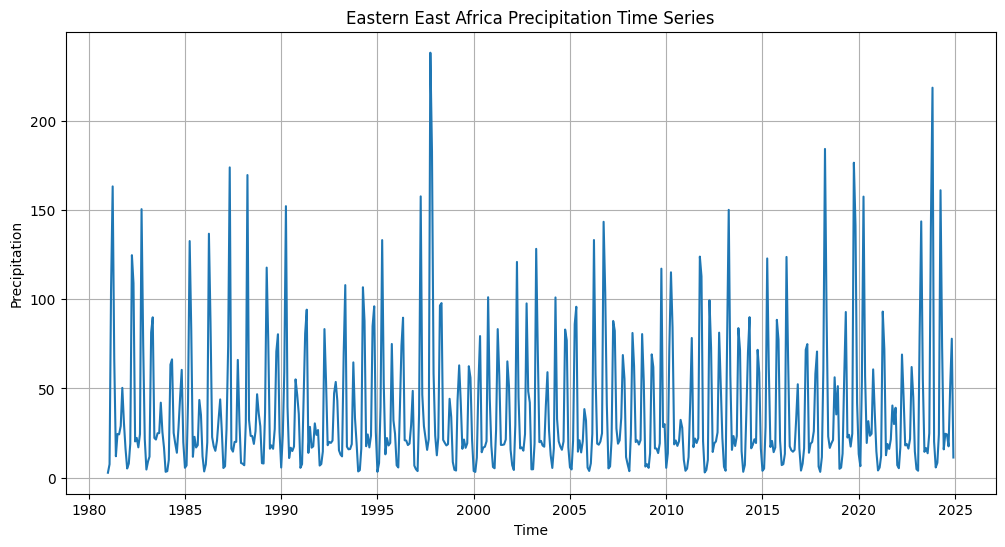

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(eea_ts.index, eea_ts.values)
plt.xlabel('Time')
plt.ylabel('Precipitation')
plt.title('Eastern East Africa Precipitation Time Series')
plt.grid(True)
plt.show()

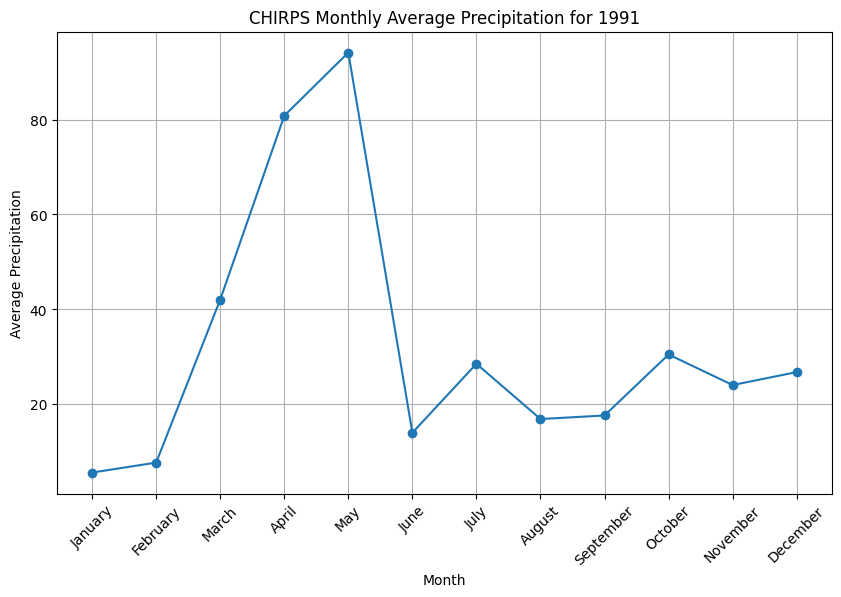

In [ ]:
# year 1991
eea_data_df['Year'] = eea_data_df['time'].dt.year
eea_data_df['Month'] = eea_data_df['time'].dt.month

eea_1991 = eea_data_df[eea_data_df['Year'] == 1991]

# Grouping by month to calculate the monthly average of 'prec'
eea_1991_monthly_avg = eea_1991.groupby('Month')['precip'].mean().reset_index()

# Mapping month numbers to month names
eea_1991_monthly_avg['Month_Name'] = eea_1991_monthly_avg['Month'].apply(lambda x: calendar.month_name[x])

# Plot with month name mapped
plt.figure(figsize=(10, 6))
plt.plot(eea_1991_monthly_avg['Month_Name'], eea_1991_monthly_avg['precip'], marker='o')
plt.title('CHIRPS Monthly Average Precipitation for 1991')
plt.xlabel('Month')
plt.ylabel('Average Precipitation')
plt.grid(True)
plt.xticks(rotation=45)  # Rotating x-axis labels for better readability
plt.show()

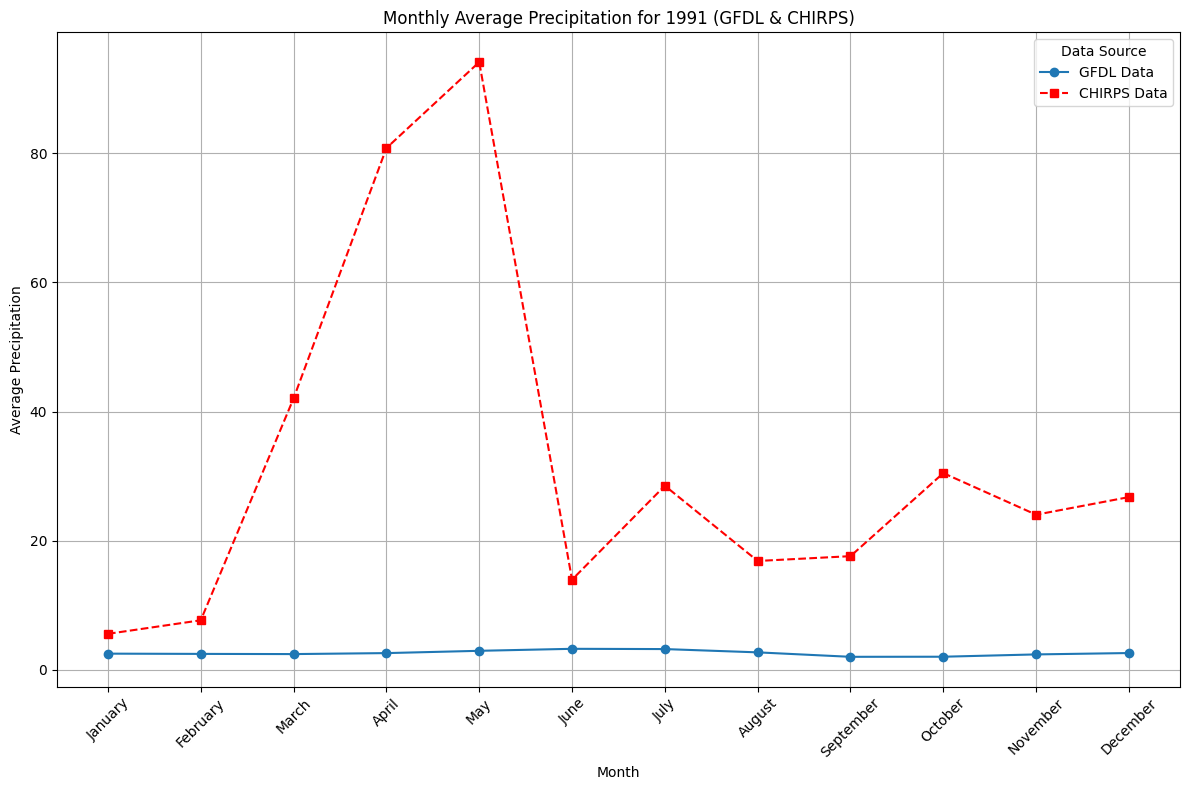

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import calendar

# Extracting Year and Month
nmme_gfdl_data['Year'] = nmme_gfdl_data['forcast_reference_time'].dt.year
nmme_gfdl_data['Month'] = nmme_gfdl_data['forcast_reference_time'].dt.month

# Filtering data for the year 1991
gfdl_1991 = nmme_gfdl_data[nmme_gfdl_data['Year'] == 1991]

# Grouping by Month to calculate the monthly average of 'prec'
gfdl_1991_monthly_avg = gfdl_1991.groupby('Month')['prec'].mean().reset_index()

# Mapping month numbers to month names
gfdl_1991_monthly_avg['Month_Name'] = gfdl_1991_monthly_avg['Month'].apply(lambda x: calendar.month_name[x])

# Extracting Year and Month for EEA data
eea_data_df['Year'] = eea_data_df['time'].dt.year
eea_data_df['Month'] = eea_data_df['time'].dt.month

# Filtering EEA data for the year 1991
eea_1991 = eea_data_df[eea_data_df['Year'] == 1991]

# Grouping by Month to calculate the monthly average of 'precip'
eea_1991_monthly_avg = eea_1991.groupby('Month')['precip'].mean().reset_index()

# Mapping month numbers to month names
eea_1991_monthly_avg['Month_Name'] = eea_1991_monthly_avg['Month'].apply(lambda x: calendar.month_name[x])

# Plotting the data
plt.figure(figsize=(12, 8))

# Plotting GFDL data
plt.plot(gfdl_1991_monthly_avg['Month_Name'], gfdl_1991_monthly_avg['prec'], marker='o', label='GFDL Data')

# Plotting CHIRPS data
plt.plot(eea_1991_monthly_avg['Month_Name'], eea_1991_monthly_avg['precip'], marker='s', linestyle='--', color='red', label='CHIRPS Data')

plt.title('Monthly Average Precipitation for 1991 (GFDL & CHIRPS)')
plt.xlabel('Month')
plt.ylabel('Average Precipitation')
plt.grid(True)
plt.xticks(rotation=45)  # Rotating x-axis labels for better readability
plt.legend(title='Data Source')
plt.tight_layout()
plt.show()


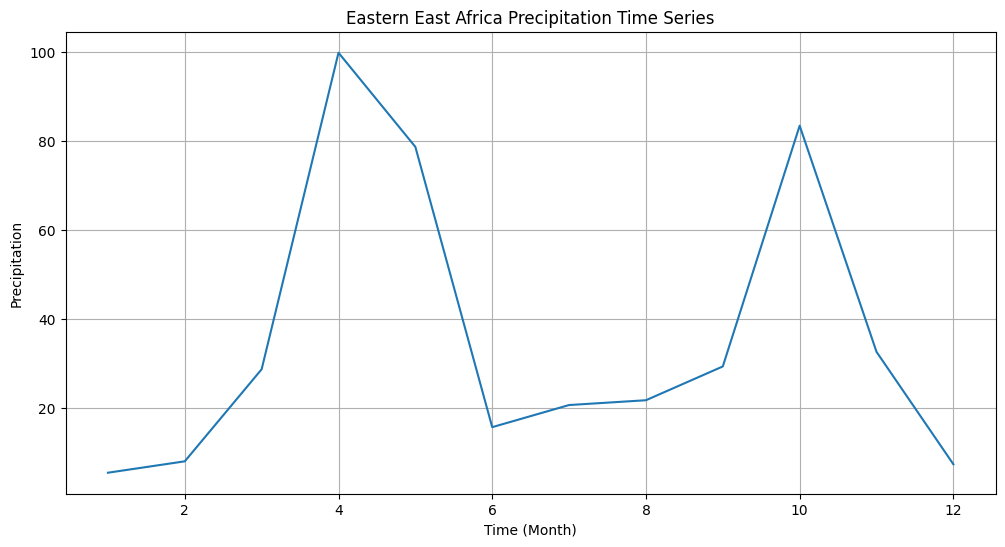

In [ ]:
# Monthly average across years
monthly_precip_avg = eea_data_df.groupby('month')['precip'].mean()
monthly_precip_avg = monthly_precip_avg.reset_index()
plt.figure(figsize=(12, 6))
plt.plot(monthly_precip_avg['month'],monthly_precip_avg['precip'])
plt.xlabel('Time (Month)')
plt.ylabel('Precipitation')
plt.title('Eastern East Africa Precipitation Time Series')
plt.grid(True)
plt.show()
#bars = monthly_precip_avg.plot(kind='line', color='blue')

# South Sudan

In [ ]:
min_lat = 3.5
max_lat = 12.5
min_lon = 25
max_lon = 35

ssudan_data = chirps_ts.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
ssudan_data_df = ssudan_data.to_dataframe().reset_index()
ssudan_data_df['month'] = ssudan_data_df['time'].dt.month
ssudan_data_df


,time,latitude,longitude,precip,month
0,1981-01-01,3.524998,25.024994,41.080067,1
1,1981-01-01,3.524998,25.074997,40.298447,1
2,1981-01-01,3.524998,25.125000,40.689270,1
3,1981-01-01,3.524998,25.175003,41.437103,1
4,1981-01-01,3.524998,25.224991,41.519989,1
...,...,...,...,...,...
19007995,2024-12-01,12.474998,34.774994,0.074598,12
19007996,2024-12-01,12.474998,34.824997,0.074303,12
19007997,2024-12-01,12.474998,34.875000,0.073936,12
19007998,2024-12-01,12.474998,34.925003,0.082645,12


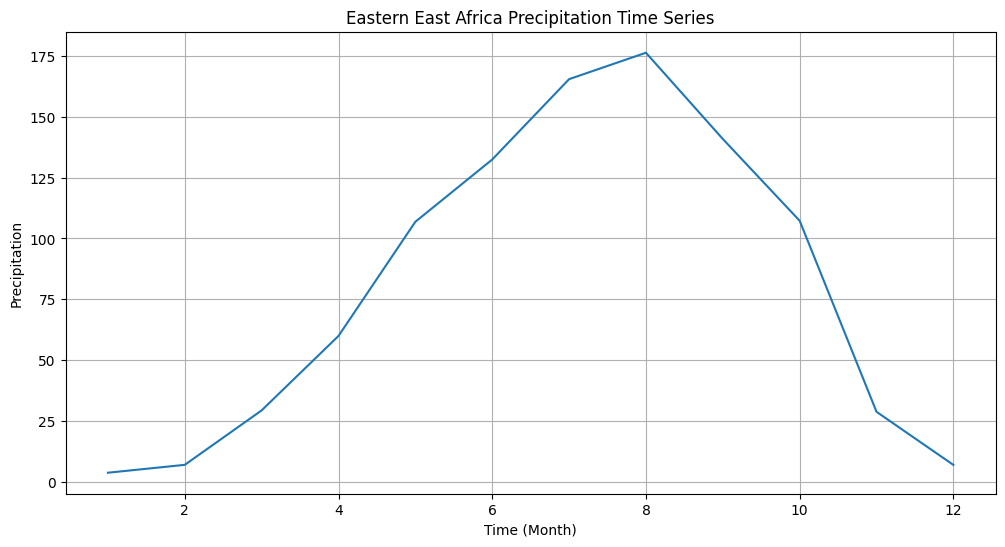

In [ ]:
ssudan_monthly_pre_avg = ssudan_data_df.groupby('month')['precip'].mean()
ssudan_monthly_pre_avg = ssudan_monthly_pre_avg.reset_index()
plt.figure(figsize=(12, 6))
plt.plot(ssudan_monthly_pre_avg['month'],ssudan_monthly_pre_avg['precip'])
plt.xlabel('Time (Month)')
plt.ylabel('Precipitation')
plt.title('South Sudan Precipitation Time Series')
plt.grid(True)
plt.show()

# Ukraine

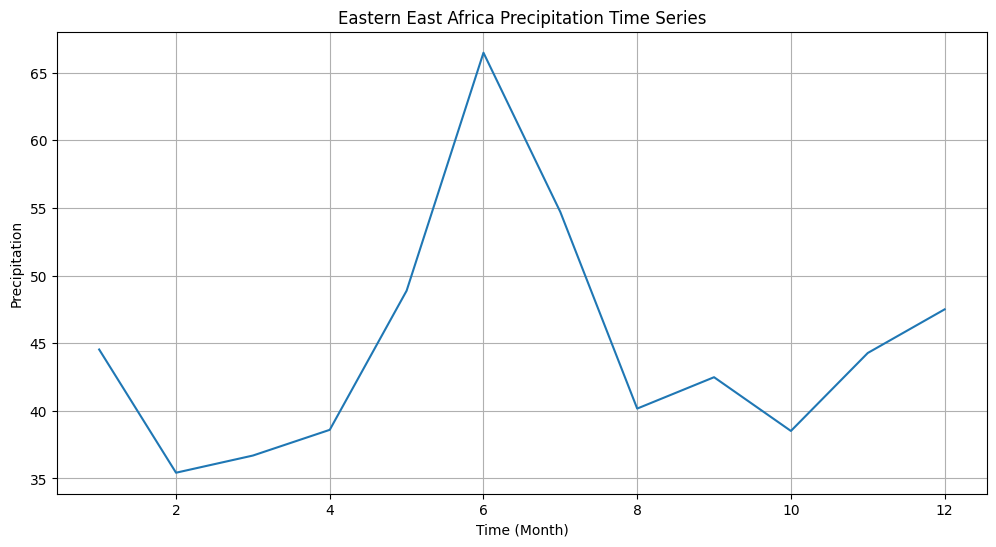

In [ ]:
min_lat = 45
max_lat = 51
min_lon = 31
max_lon = 40

ukr_data = chirps_ts.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
ukr_data_df = ukr_data.to_dataframe().reset_index()
ukr_data_df['month'] = ukr_data_df['time'].dt.month

ukr_monthly_pre_avg = ukr_data_df.groupby('month')['precip'].mean()
ukr_monthly_pre_avg = ukr_monthly_pre_avg.reset_index()
plt.figure(figsize=(12, 6))
plt.plot(ukr_monthly_pre_avg['month'],ukr_monthly_pre_avg['precip'])
plt.xlabel('Time (Month)')
plt.ylabel('Precipitation')
plt.title('Ukraine Precipitation Time Series')
plt.grid(True)
plt.show()

# Southern Africa

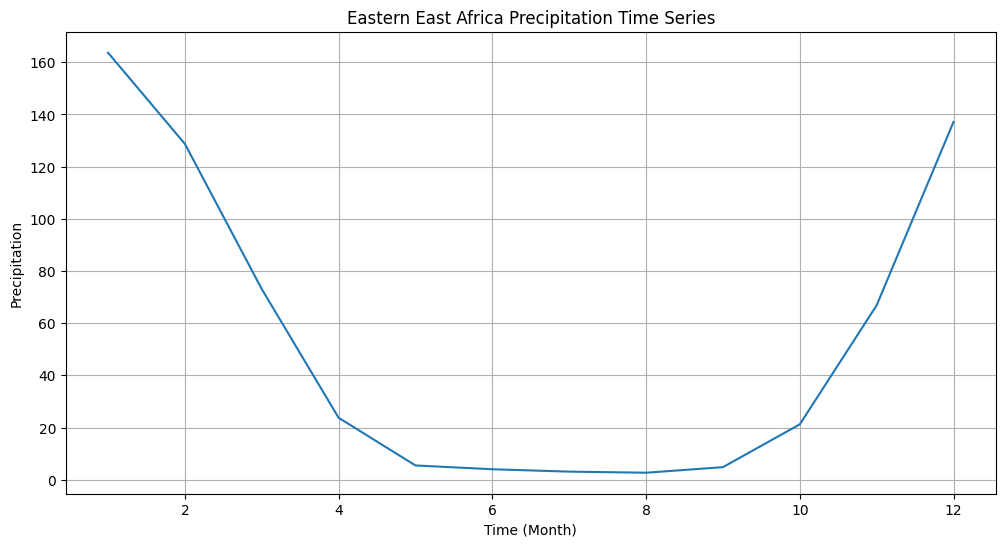

In [ ]:
min_lat = -23
max_lat = -15
min_lon = 25
max_lon = 34

sa_data = chirps_ts.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
sa_data_df = sa_data.to_dataframe().reset_index()
sa_data_df['month'] = sa_data_df['time'].dt.month

sa_monthly_pre_avg = sa_data_df.groupby('month')['precip'].mean()
sa_monthly_pre_avg = sa_monthly_pre_avg.reset_index()
plt.figure(figsize=(12, 6))
plt.plot(sa_monthly_pre_avg['month'],sa_monthly_pre_avg['precip'])
plt.xlabel('Time (Month)')
plt.ylabel('Precipitation')
plt.title('Southern Africa Precipitation Time Series')
plt.grid(True)
plt.show()

# West Africa

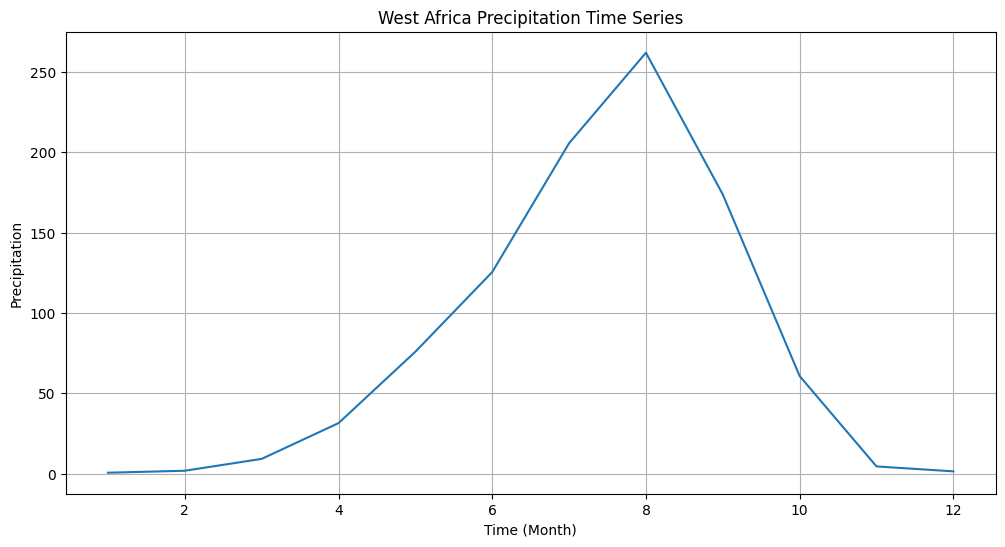

In [ ]:
min_lat = 10
max_lat = 13.5
min_lon = -10
max_lon = 0

wa_data = chirps_ts.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
wa_data_df = wa_data.to_dataframe().reset_index()
wa_data_df['month'] = wa_data_df['time'].dt.month

wa_monthly_pre_avg = wa_data_df.groupby('month')['precip'].mean()
wa_monthly_pre_avg = wa_monthly_pre_avg.reset_index()
plt.figure(figsize=(12, 6))
plt.plot(wa_monthly_pre_avg['month'],wa_monthly_pre_avg['precip'])
plt.xlabel('Time (Month)')
plt.ylabel('Precipitation')
plt.title('West Africa Precipitation Time Series')
plt.grid(True)
plt.show()

In [ ]:
print(sri_lanka_data_df)

Empty DataFrame
Columns: [time, latitude, longitude, precip, month]
Index: []


# Sri Lanka

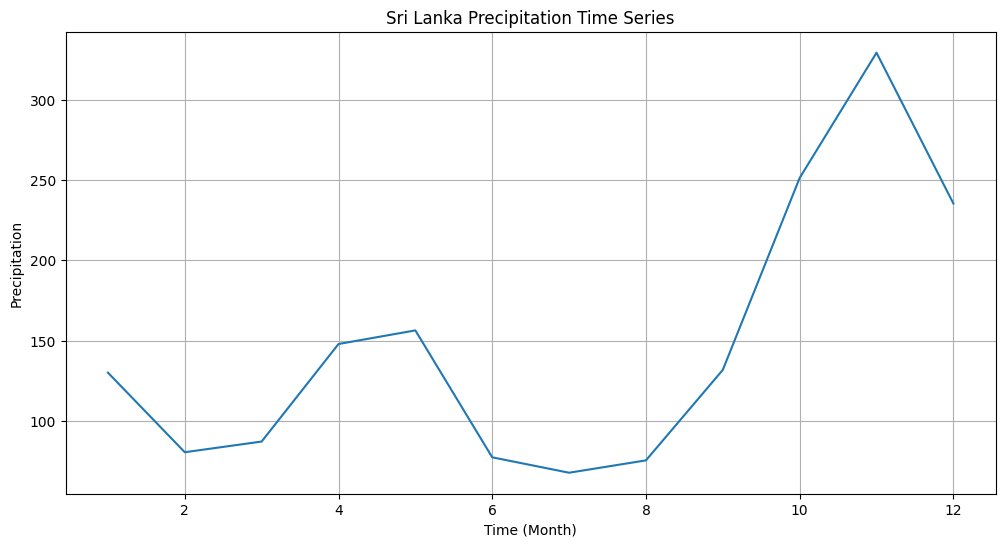

In [ ]:
min_lat = 5.5
max_lat = 10
min_lon = 79.5
max_lon = 82

sri_lanka_data = chirps_ts.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
sri_lanka_data_df = sri_lanka_data.to_dataframe().reset_index()
sri_lanka_data_df['month'] = sri_lanka_data_df['time'].dt.month

srilanka_monthly_pre_avg = sri_lanka_data_df.groupby('month')['precip'].mean()
srilanka_monthly_pre_avg = srilanka_monthly_pre_avg.reset_index()
plt.figure(figsize=(12, 6))
plt.plot(srilanka_monthly_pre_avg['month'],srilanka_monthly_pre_avg['precip'])
plt.xlabel('Time (Month)')
plt.ylabel('Precipitation')
plt.title('Sri Lanka Precipitation Time Series')
plt.grid(True)
plt.show()

# Lake Victoria Basin

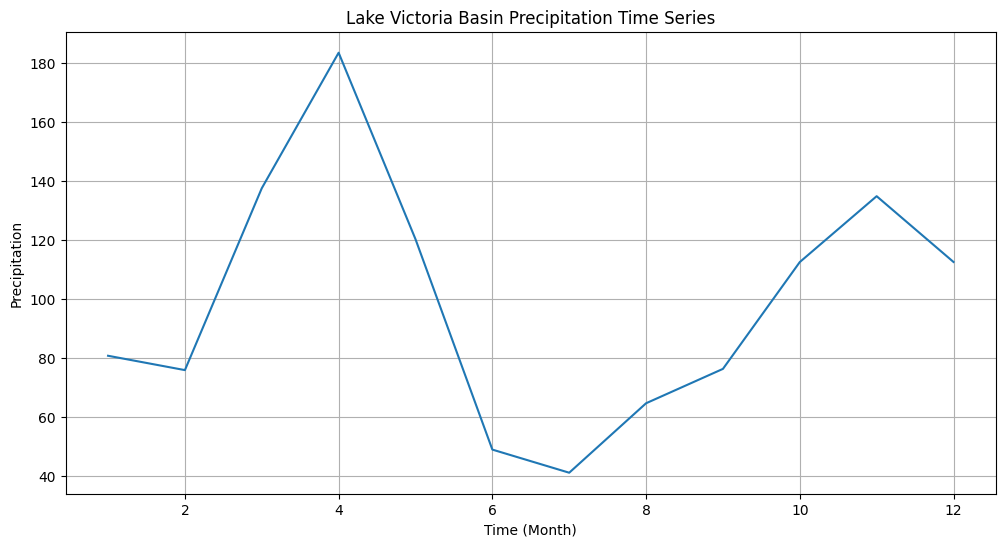

In [ ]:
min_lat = -4
max_lat = 1.5
min_lon = 29
max_lon = 36

lake_vic_data = chirps_ts.sel(latitude=slice(min_lat, max_lat), longitude=slice(min_lon, max_lon))
lake_vic_data_df = lake_vic_data.to_dataframe().reset_index()
lake_vic_data_df['month'] = lake_vic_data_df['time'].dt.month

lake_vic_monthly_pre_avg = lake_vic_data_df.groupby('month')['precip'].mean()
lake_vic_monthly_pre_avg = lake_vic_monthly_pre_avg.reset_index()
plt.figure(figsize=(12, 6))
plt.plot(lake_vic_monthly_pre_avg['month'],lake_vic_monthly_pre_avg['precip'])
plt.xlabel('Time (Month)')
plt.ylabel('Precipitation')
plt.title('Lake Victoria Basin Precipitation Time Series')
plt.grid(True)
plt.show()